# Comparison of Diversification Approaches — final comparison

All strategies go through the shared `backtest.rolling_backtest`, so they use the same universe,
the same single-factor covariance estimate, the same delisting and turnover conventions, and
are scored with the same metrics (`evaluation.performance_table`).

| Strategy | Constructor | Code |
|---|---|---|
| Equally weighted | `equal_weight` | `benchmarks.py` |
| Value weighted | `value_weight` | `benchmarks.py` |
| Minimum risk | `min_risk_closed_form` | `min_risk.py` |
| Maximum diversification | `max_diversification_closed_form` | `max_diversification.py` |
| Risk parity | `risk_parity` | `risk_parity.py` |

| Section | Content |
|---|---|
| §1–2 | Setup, data, data-quality checks |
| §3 | Parameters and universe summary |
| §4 | Backtest of every strategy in `STRATEGIES`, alignment checks |
| §5 | Summary statistics (format of Exhibit 1, Clarke, de Silva and Thorley 2013) |
| §6 | Cumulative returns (format of Exhibit 4, Clarke, de Silva and Thorley 2006) |

| §7–8 | Drawdowns, subperiods, diversification and risk concentration |

**Adding a strategy:** put its constructor in `STRATEGIES` (§4) and re-run; the table and chart pick it up.

## 1. Setup

In [1]:
import os, sys, warnings
# Run from the project root whether the kernel starts there or in analysis/.
if not os.path.exists("data") and os.path.exists(os.path.join("..", "data")):
    os.chdir("..")
sys.path.insert(0, os.getcwd())
# numpy on macOS Accelerate emits spurious matmul RuntimeWarnings; results are unaffected.
warnings.filterwarnings("ignore", category=RuntimeWarning, message=".*encountered in matmul")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from backtest import rolling_backtest, summarize
from min_risk import min_risk_closed_form
from risk_parity import risk_parity
from max_diversification import max_diversification_closed_form, diversification_ratio, optimality_residuals
from benchmarks import equal_weight, value_weight
from evaluation import (returns_from_panel, performance_table,
                                  cumulative_returns, drawdowns, subperiod_table,
                                  estimate_covs, risk_concentration, check_alignment)
from project_data import download_crsp, data_quality_report, universe_summary

pd.set_option("display.width", 140)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
plt.rcParams.update({
    "figure.figsize": (11, 4.5), "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False, "lines.linewidth": 1.5,
})

# Same colours and names as analysis/risk_parity.ipynb
COLORS = {"max_div": "#eb6834", "min_risk": "#2a78d6", "risk_parity": "#1baf7a", "ew": "#eda100", "vw": "#e87ba4"}
LABELS = {"max_div": "Maximum diversification", "min_risk": "Minimum risk", "risk_parity": "Risk parity",
          "ew": "Equally weighted", "vw": "Value weighted"}

## 2. Data

* `data/crsp_msf_v2.parquet` — CRSP monthly stock file (US common stocks), 1990-01 to 2025-12.
  If the file is missing, it is downloaded from WRDS with your own account.
* `data/MktRf.csv` — market excess return and risk-free rate (Kenneth French, percentage points → divided by 100).

In [2]:
if os.path.exists("data/crsp_msf_v2.parquet"):
    raw = download_crsp()
else:
    import wrds
    raw = download_crsp(wrds.Connection())

data_quality_report(raw).to_frame("value")

Loaded data/crsp_msf_v2.parquet: (2179752, 14)


,value
rows,2179752
unique permnos,18905
first month,199001
last month,202512
"duplicate (permno, month)",0
missing mthret (%),1.8270
missing mthcap (%),1.7930
returns < -100%,0
returns > +100%,7313
returns > +300%,526


In [3]:
# Same preparation as the other notebooks: NYSE / NYSE American / Nasdaq only, keyed on yyyymm.
assert not raw.duplicated(["yyyymm", "permno"]).any(), "duplicate stock-month observations"
crsp = raw[raw.primaryexch.isin(["N", "A", "Q"])]
rets = crsp.pivot_table(index="yyyymm", columns="permno", values="mthret")
caps = crsp.pivot_table(index="yyyymm", columns="permno", values="mthcap")

ff = pd.read_csv("data/MktRf.csv", index_col=0)
mkt = (ff["Mkt-RF"] / 100.0).reindex(rets.index)
rf = (ff["RF"] / 100.0).reindex(rets.index)

assert not mkt.isna().any() and not rf.isna().any(), "MktRf does not cover the CRSP window"
assert 0.03 < mkt.std() < 0.07, "Mkt-RF units look wrong -- did you divide by 100?"
assert rets.min().min() >= -1.0, "a return below -100% is impossible"
print(f"panel {rets.shape[0]} months x {rets.shape[1]:,} stocks, {rets.index[0]}..{rets.index[-1]}")

panel 432 months x 18,898 stocks, 199001..202512


## 3. Parameters and universe summary

In [4]:
START_YEAR, END_YEAR, T, N = 1995, 2025, 60, 500

idx = rets.index
i_first = idx.get_loc(START_YEAR * 100 + 1) - 1   # last in-sample month before 1995-01
i_last = idx.get_loc(END_YEAR * 100 + 12) - 1
print(f"rebalances {idx[i_first]}..{idx[i_last]}, out-of-sample {idx[i_first + 1]}..{idx[i_last + 1]}, "
      f"{i_last - i_first + 1} months")

rebalances 199412..202511, out-of-sample 199501..202512, 372 months


In [5]:
us = universe_summary(rets, caps, T, N, start=idx[i_first], end=idx[i_last])
us.describe().T

,count,mean,std,min,25%,50%,75%,max
n_eligible,372.0000,"3,252.6478",515.8474,"2,592.0000","2,706.5000","3,130.5000","3,818.2500","4,059.0000"
n_universe,372.0000,500.0000,0.0000,500.0000,500.0000,500.0000,500.0000,500.0000
min_cap_musd,372.0000,"5,119.6468","2,689.3526","1,475.2260","2,803.8285","4,249.1475","6,763.4747","11,849.6783"
median_cap_musd,372.0000,"13,840.5208","8,117.7502","3,472.9826","7,573.1825","11,003.6787","17,964.5626","35,353.6271"
share_of_total_cap,372.0000,0.8026,0.0391,0.7114,0.7834,0.8035,0.8193,0.8943
top10_weight_vw,372.0000,0.2260,0.0489,0.1665,0.1906,0.2097,0.2452,0.4051
new_names,371.0000,12.4690,4.6523,3.0000,9.5000,11.0000,14.0000,34.0000
missing_next_ret,372.0000,1.5376,1.4889,0.0000,0.0000,1.0000,2.0000,9.0000


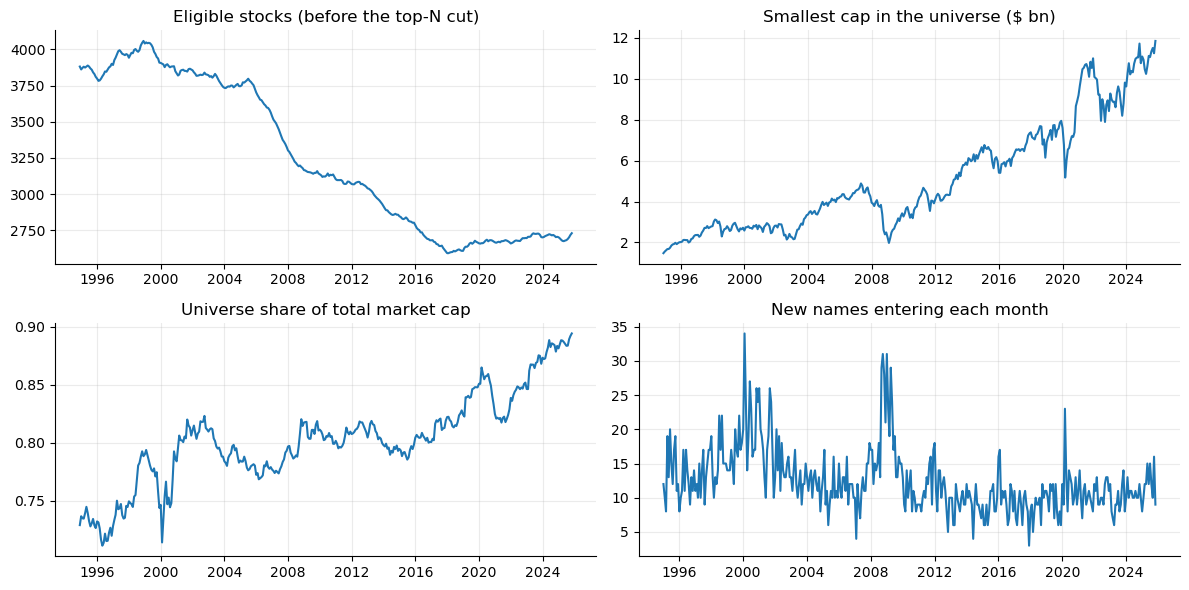

In [6]:
fig, ax = plt.subplots(2, 2, figsize=(12, 6))
when_us = pd.PeriodIndex([str(d) for d in us.index], freq="M").to_timestamp()
ax[0, 0].plot(when_us, us.n_eligible); ax[0, 0].set_title("Eligible stocks (before the top-N cut)")
ax[0, 1].plot(when_us, us.min_cap_musd / 1e3); ax[0, 1].set_title("Smallest cap in the universe ($ bn)")
ax[1, 0].plot(when_us, us.share_of_total_cap); ax[1, 0].set_title("Universe share of total market cap")
ax[1, 1].plot(when_us, us.new_names); ax[1, 1].set_title("New names entering each month")
plt.tight_layout(); plt.show()

## 4. Backtest

One call runs every strategy on the same universe and covariance estimate each month.
`check_alignment` then confirms identical months, rebalance dates and universes, and fully
invested long-only weights.

In [7]:
STRATEGIES = {
    "ew": equal_weight,
    "vw": value_weight,
    "min_risk": min_risk_closed_form,
    "risk_parity": risk_parity,
    "max_div": max_diversification_closed_form,
}

panel, weights = rolling_backtest(rets, caps, mkt, rf, T=T, n=N,
                                  start=idx[i_first], end=idx[i_last],
                                  constructors=STRATEGIES)
returns = returns_from_panel(panel)[list(STRATEGIES)]

check_alignment(returns, weights, asset_returns=rets)
assert len(returns) == i_last - i_first + 1
print(f"{len(returns)} months x {returns.shape[1]} strategies; alignment checks passed")

372 months x 5 strategies; alignment checks passed


## 5. Summary statistics

Conventions (`evaluation.py`): geometric annualised return; volatility and Sharpe
ratio on **excess** returns; maximum drawdown on the compounded path; beta against the market
excess return; one-way turnover against the previous month's **drifted** weights.
The table is cross-checked against `backtest.summarize`.

In [8]:
table = performance_table(returns, weights, rf=rf, asset_returns=rets, mkt=mkt)

ref = summarize(panel)
for col in ["ann_return", "ann_vol", "sharpe", "max_drawdown", "ann_turnover"]:
    gap = np.abs(table[col] - ref.loc[table.index, col]).max()
    assert gap < 1e-12, f"{col} disagrees with backtest.summarize by {gap:.1e}"

table.rename(index=lambda k: LABELS.get(k, k))

,months,ann_return,ann_vol,sharpe,max_drawdown,cum_return,ann_turnover,beta
Equally weighted,372.0000,0.1163,0.1574,0.6313,-0.5170,29.2868,0.6166,0.9769
Value weighted,372.0000,0.1155,0.1482,0.6557,-0.4913,28.5812,0.1001,0.9437
Minimum risk,372.0000,0.0820,0.1272,0.4992,-0.3755,10.5178,1.1662,0.3395
Risk parity,372.0000,0.1162,0.1404,0.6890,-0.4890,29.2089,0.6241,0.8457
Maximum diversification,372.0000,0.1035,0.1411,0.6037,-0.5362,20.1562,1.6036,0.6725


## 6. Cumulative returns

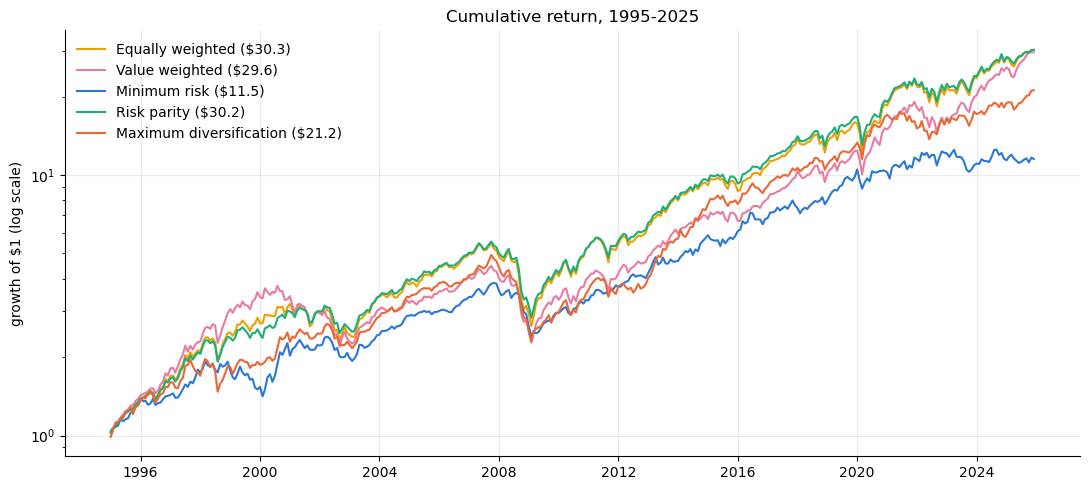

In [9]:
when = pd.PeriodIndex([str(d) for d in returns.index], freq="M").to_timestamp()
wealth = 1.0 + cumulative_returns(returns)

fig, ax = plt.subplots(figsize=(11, 5))
for k in returns.columns:
    ax.plot(when, wealth[k], color=COLORS.get(k),
            label=f"{LABELS.get(k, k)} (${wealth[k].iloc[-1]:.1f})")
ax.set_yscale("log"); ax.set_ylabel("growth of $1 (log scale)")
ax.set_title(f"Cumulative return, {START_YEAR}-{END_YEAR}")
ax.legend(frameon=False, loc="upper left")
plt.tight_layout(); plt.show()

## 7. Drawdowns and economic subperiods

The running peak includes initial wealth of $1. All five portfolios are evaluated over the same subperiods; results are gross of transaction costs.

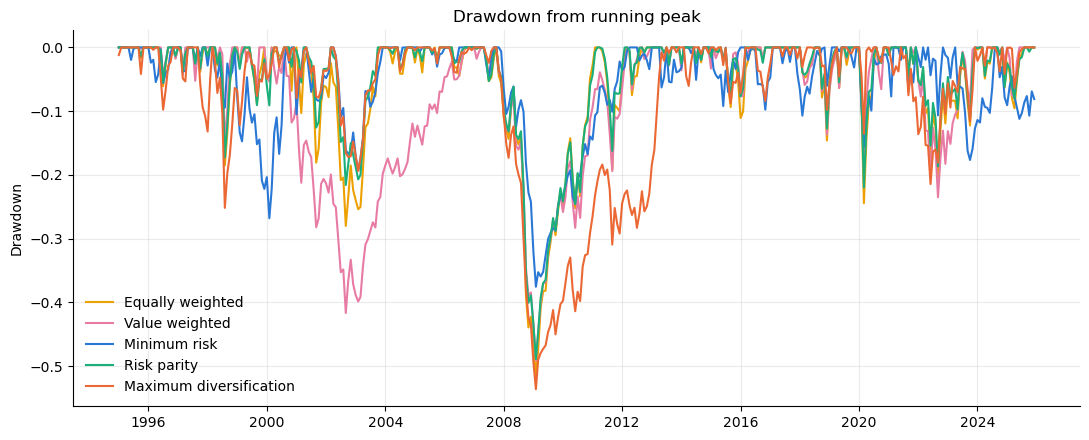

ann_return  ann_vol  sharpe  max_drawdown   beta
period    strategy                                                                 
1995–1999 Equally weighted             0.2316   0.1395  1.2173       -0.1851 0.9350
          Value weighted               0.2885   0.1396  1.5466       -0.1522 0.9512
          Minimum risk                 0.0848   0.1308  0.3070       -0.2219 0.3382
          Risk parity                  0.2067   0.1302  1.1347       -0.1729 0.8481
          Maximum diversification      0.1391   0.1639  0.5760       -0.2518 0.9512
2000–2009 Equally weighted             0.0408   0.1701  0.1621       -0.5170 0.9781
          Value weighted              -0.0033   0.1545 -0.1196       -0.4913 0.9145
          Minimum risk                 0.0702   0.1340  0.3726       -0.3755 0.3184
          Risk parity                  0.0539   0.1459  0.2484       -0.4890 0.7905
          Maximum diversification      0.0439   0.1353  0.1855       -0.5362 0.5136
2010–2019 Equally weighted             0.1420   0.1344  1.0221       -0.1914 1.0276
          Value weighted               0.1366   0.1242  1.0566       -0.1614 0.9559
          Minimum risk                 0.1275   0.1052  1.1493       -0.1071 0.2977
          Risk parity                  0.1448   0.1194  1.1545       -0.1624 0.9097
          Maximum diversification      0.1589   0.1252  1.2065       -0.1539 0.7482
2020–2025 Equally weighted             0.1127   0.1825  0.5323       -0.2444 0.9841
          Value weighted               0.1565   0.1719  0.7808       -0.2351 0.9627
          Minimum risk                 0.0267   0.1448  0.0688       -0.1766 0.4341
          Risk parity                  0.1036   0.1684  0.5131       -0.2200 0.8982
          Maximum diversification      0.0862   0.1536  0.4418       -0.2144 0.7069

In [10]:
dd = drawdowns(returns)
fig, ax = plt.subplots(figsize=(11, 4.5))
for k in returns.columns:
    ax.plot(when, dd[k], color=COLORS[k], label=LABELS[k])
ax.set(ylabel="Drawdown", title="Drawdown from running peak")
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

PERIODS = [(199501, 199912, "1995–1999"), (200001, 200912, "2000–2009"),
           (201001, 201912, "2010–2019"), (202001, 202512, "2020–2025")]
sub = subperiod_table(returns, weights, periods=PERIODS, rf=rf, asset_returns=rets, mkt=mkt)
display(sub[["ann_return", "ann_vol", "sharpe", "max_drawdown", "beta"]]
        .rename(index=LABELS, level="strategy"))

## 8. Diversification and risk concentration

DR uses model-implied asset volatilities and the same covariance for every strategy. Effective risk contribution count measures concentration across stocks, rather than independent risk sources. The market variance share measures factor concentration. MaxDiv maximizes estimated DR; it need not have the most holdings or the highest realized Sharpe.

MaxDiv maximum relative KKT residual: 2.85e-09


,div_ratio,n_held,eff_n_weight,eff_n_risk,top10_rc_share,systematic_share
Equally weighted,2.1167,500.0000,500.0000,437.0646,0.0453,0.9912
Value weighted,1.9459,500.0000,112.2817,102.9371,0.2480,0.9755
Minimum risk,2.8875,45.1156,25.3440,25.3440,0.5398,0.7316
Risk parity,2.2572,500.0000,423.6350,500.0000,0.0200,0.9893
Maximum diversification,3.6607,63.0430,36.7298,37.9566,0.4113,0.6548


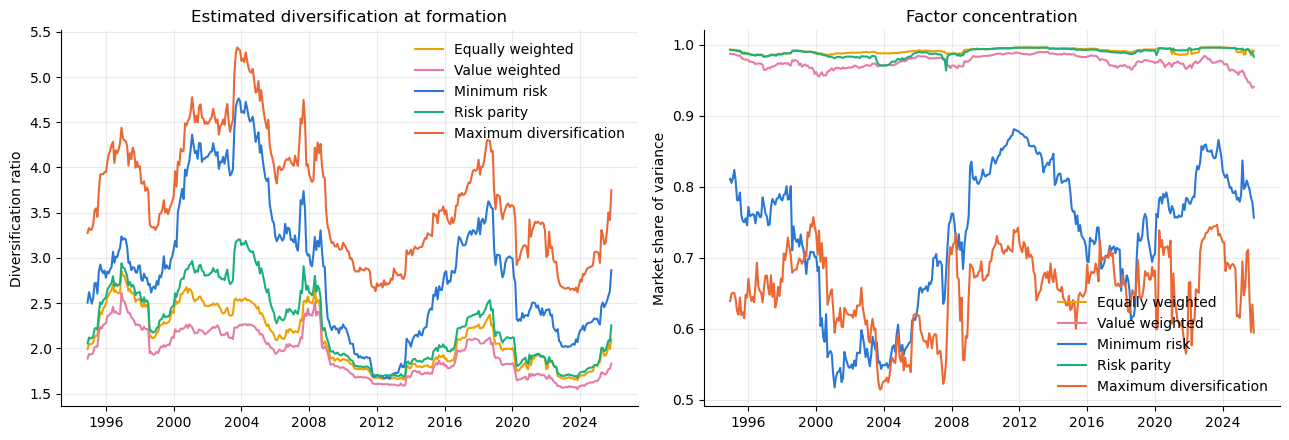

In [11]:
covs = estimate_covs(weights["max_div"], rets, mkt, rf, T=T)
conc = {k: risk_concentration(w, covs) for k, w in weights.items()}
for k, w in weights.items():
    conc[k]["div_ratio"] = pd.Series({
        t: diversification_ratio(w.loc[t].reindex(c.permno).values, c)
        for t, c in covs.items()
    })
dr = pd.DataFrame({k: c.div_ratio for k, c in conc.items()})
assert (dr.sub(dr["max_div"], axis=0).to_numpy() <= 1e-6).all()
max_kkt = max(max(optimality_residuals(
    weights["max_div"].loc[t].reindex(c.permno).values, c).values())
    for t, c in covs.items())
assert max_kkt < 1e-8
print(f"MaxDiv maximum relative KKT residual: {max_kkt:.2e}")
cols = ["div_ratio", "n_held", "eff_n_weight", "eff_n_risk", "top10_rc_share", "systematic_share"]
display(pd.DataFrame({LABELS[k]: c[cols].mean() for k, c in conc.items()}).T)

reb = pd.PeriodIndex(dr.index.astype(str), freq="M").to_timestamp()
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
for k, c in conc.items():
    ax[0].plot(reb, c.div_ratio, color=COLORS[k], label=LABELS[k])
    ax[1].plot(reb, c.systematic_share, color=COLORS[k], label=LABELS[k])
ax[0].set(ylabel="Diversification ratio", title="Estimated diversification at formation")
ax[1].set(ylabel="Market share of variance", title="Factor concentration")
ax[0].legend(frameon=False); ax[1].legend(frameon=False)
plt.tight_layout(); plt.show()

## Interpretation and limitations

Compare realized return and Sharpe alongside drawdowns, turnover and concentration. A higher estimated DR does not guarantee better out-of-sample performance. All strategies use a single-factor covariance with beta shrinkage; model error can particularly affect optimized portfolios.

The complete 60-month-history rule favors longer-listed stocks. Missing next-month returns earn RF, a simplifying assumption rather than an observed liquidation price. The download SQL filters US common stocks before saving; the cache omits those classification columns, so its provenance must be retained. Results exclude transaction costs. Position caps, HRP and alternative covariance estimates are optional extensions, rather than required components of Topic 3.

## Main findings

* Risk parity has the highest full-sample Sharpe (0.689), with returns close to EW and lower volatility. Minimum risk has the lowest volatility (12.72%) and smallest maximum drawdown (−37.55%), alongside the lowest return (8.20%).
* MaxDiv achieves the highest average estimated DR (3.661), while holding about 63 of 500 stocks. Its market variance share (65.48%) is the lowest of the five; its stock risk contributions remain concentrated. Its realized Sharpe (0.604) trails RP, EW and VW, and its annual one-way turnover (160.36%) is the highest.
* Rankings depend on the economic period: MaxDiv has the highest Sharpe in 2010–2019 (1.207), whereas VW leads in 1995–1999 and 2020–2025, and minimum risk leads in 2000–2009.
* VW has annual one-way turnover of only 10.01%. Gross performance comparisons should be read alongside these trading requirements; no net-of-cost ranking is established here.
